# SOTA AI System - Merge Compatibility Analysis

## Overview

This notebook analyzes the merge compatibility between the main branch and feature branches in the SOTA AI system project. We'll examine the git diff statistics for the `codex/implement-git-pre-commit-hooks` branch to understand potential conflicts and merge strategies.

### Branch Analysis Summary
- **Main Branch**: Latest HITL implementation (Phase 7 complete)
- **Feature Branch**: `origin/codex/implement-git-pre-commit-hooks`
- **Analysis Date**: June 14, 2025
- **Files Changed**: 36 files
- **Total Changes**: 1,332 insertions, 44 deletions

In [2]:
%pip install matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import re
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Git diff output data for origin/codex/implement-git-pre-commit-hooks
git_diff_output = """
 .env.template                       |   1 +
 .gitignore                          |   5 +-
 .ruff.toml                          |   2 +
 AGENT.md                            | 150 +++++++++++++++++
 Dockerfile.dev                      |   6 +
 Dockerfile.docs                     |   5 +
 Dockerfile.jupyter                  |   6 +
 Makefile                            | 130 ++++++++++++++
 README.md                           |  15 +-
 config/prometheus.yml               |   4 +
 config/redis.conf                   |   3 +
 docker-compose.dev.yml              | 251 +++++++++++++++++++++++++++
 docs/development/automation.md      |   3 +
 docs/development/setup.md           |   8 +
 docs/development/troubleshooting.md |   3 +
 githooks/post-commit                | 128 ++++++++++++++
 githooks/pre-commit                 | 143 ++++++++++++++++
 pyproject.toml                      |   5 +
 requirements-dev.txt                |   3 +
 requirements.txt                    |  11 +-
 scripts/benchmark_agents.py         |  13 ++
 scripts/db/init.sql                 |   5 +
 scripts/dev.sh                      | 328 ++++++++++++++++++++++++++++++++++++
 scripts/health-check.sh             |   7 +
 scripts/test_workflows.py           |  13 ++
 scripts/utils.sh                    |   8 +
 scripts/validate_workflows.py       |  13 ++
 tests/agents/__init__.py            |   0
 tests/agents/test_placeholder.py    |   2 +
 tests/critical/__init__.py          |   0
 tests/critical/test_placeholder.py  |   2 +
 tests/workflows/__init__.py         |   0
 tests/workflows/test_placeholder.py |   2 +
 tools/jest_tool.py                  |  36 ++--
 tools/markdown_tool.py              |  12 +-
 tools/supabase_tool.py              |  53 +++---
 36 files changed, 1332 insertions(+), 44 deletions()
"""

print("✅ Git diff data loaded successfully")
print(f"📊 Raw data length: {len(git_diff_output.strip().split('\n'))} lines")

✅ Git diff data loaded successfully
📊 Raw data length: 37 lines


In [4]:
def parse_git_diff_stats(diff_output):
    """
    Parse git diff --stat output to extract file changes information
    """
    files_data = []
    lines = diff_output.strip().split('\n')
    
    # Skip empty lines and summary line
    for line in lines:
        line = line.strip()
        if not line or 'files changed' in line:
            continue
            
        # Parse file changes using regex
        # Format: filename | changes +/-
        match = re.match(r'^(.+?)\s+\|\s+(\d+)\s*(.*)$', line)
        if match:
            filename = match.group(1).strip()
            changes = int(match.group(2))
            change_type = match.group(3).strip()
            
            # Determine operation type
            if '+' in change_type and '-' in change_type:
                operation = 'modified'
                insertions = change_type.count('+')
                deletions = change_type.count('-')
            elif '+' in change_type:
                operation = 'added/modified'
                insertions = changes
                deletions = 0
            elif '-' in change_type:
                operation = 'deleted/modified'
                insertions = 0
                deletions = changes
            else:
                operation = 'unknown'
                insertions = changes
                deletions = 0
                
            # Extract file extension
            file_ext = Path(filename).suffix.lower() if '.' in filename else 'no_extension'
            
            files_data.append({
                'filename': filename,
                'changes': changes,
                'operation': operation,
                'insertions': insertions,
                'deletions': deletions,
                'file_extension': file_ext,
                'directory': str(Path(filename).parent) if '/' in filename else 'root'
            })
    
    return pd.DataFrame(files_data)

# Parse the git diff data
df = parse_git_diff_stats(git_diff_output)
print(f"✅ Parsed {len(df)} files from git diff")
print(f"📈 Total insertions: {df['insertions'].sum()}")
print(f"📉 Total deletions: {df['deletions'].sum()}")
print(f"🔄 Net change: +{df['insertions'].sum() - df['deletions'].sum()} lines")

# Display first few rows
print("\n📋 Sample of parsed data:")
print(df.head())

✅ Parsed 36 files from git diff
📈 Total insertions: 1253
📉 Total deletions: 9
🔄 Net change: +1244 lines

📋 Sample of parsed data:
         filename  changes       operation  insertions  deletions  \
0   .env.template        1  added/modified           1          0   
1      .gitignore        5        modified           1          1   
2      .ruff.toml        2  added/modified           2          0   
3        AGENT.md      150  added/modified         150          0   
4  Dockerfile.dev        6  added/modified           6          0   

  file_extension directory  
0      .template      root  
1                     root  
2          .toml      root  
3            .md      root  
4           .dev      root  


In [5]:
# Analyze changes by file type and category
def categorize_files(df):
    """
    Categorize files by type and purpose
    """
    categories = []
    
    for _, row in df.iterrows():
        filename = row['filename'].lower()
        ext = row['file_extension']
        
        if ext in ['.py']:
            if 'test' in filename:
                category = 'Tests'
            elif filename.startswith('tools/'):
                category = 'Tools'
            else:
                category = 'Python Code'
        elif ext in ['.md']:
            category = 'Documentation'
        elif ext in ['.yml', '.yaml']:
            category = 'Configuration'
        elif ext in ['.sh']:
            category = 'Scripts'
        elif ext in ['.toml', '.txt', '.ini']:
            category = 'Config Files'
        elif 'dockerfile' in filename:
            category = 'Docker'
        elif filename in ['makefile', 'makefile.mk'] or 'makefile' in filename:
            category = 'Build System'
        elif ext == '.sql':
            category = 'Database'
        elif ext == 'no_extension':
            if 'hook' in filename or filename.startswith('githooks/'):
                category = 'Git Hooks'
            else:
                category = 'Other'
        else:
            category = 'Other'
            
        categories.append(category)
    
    df['category'] = categories
    return df

# Apply categorization
df = categorize_files(df)

# Summary statistics
print("📊 CHANGE ANALYSIS SUMMARY")
print("=" * 50)
print(f"Total Files Changed: {len(df)}")
print(f"Total Insertions: {df['insertions'].sum():,}")
print(f"Total Deletions: {df['deletions'].sum():,}")
print(f"Net Lines Added: {df['insertions'].sum() - df['deletions'].sum():,}")

print("\n📁 CHANGES BY CATEGORY:")
category_stats = df.groupby('category').agg({
    'filename': 'count',
    'insertions': 'sum',
    'deletions': 'sum',
    'changes': 'sum'
}).round(2)
category_stats.columns = ['Files', 'Insertions', 'Deletions', 'Total Changes']
category_stats = category_stats.sort_values('Total Changes', ascending=False)
print(category_stats)

print("\n🔍 TOP 10 FILES BY CHANGES:")
top_files = df.nlargest(10, 'changes')[['filename', 'category', 'changes', 'insertions', 'deletions']]
print(top_files.to_string(index=False))

📊 CHANGE ANALYSIS SUMMARY
Total Files Changed: 36
Total Insertions: 1,253
Total Deletions: 9
Net Lines Added: 1,244

📁 CHANGES BY CATEGORY:
               Files  Insertions  Deletions  Total Changes
category                                                  
Scripts            3         343          0            343
Git Hooks          2         271          0            271
Configuration      2         255          0            255
Documentation      5         165          1            179
Build System       1         130          0            130
Tools              3           6          6            101
Python Code        2          26          0             26
Config Files       4          11          1             21
Tests              7          19          0             19
Docker             3          17          0             17
Other              3           5          1              9
Database           1           5          0              5

🔍 TOP 10 FILES BY CHANGES:
      

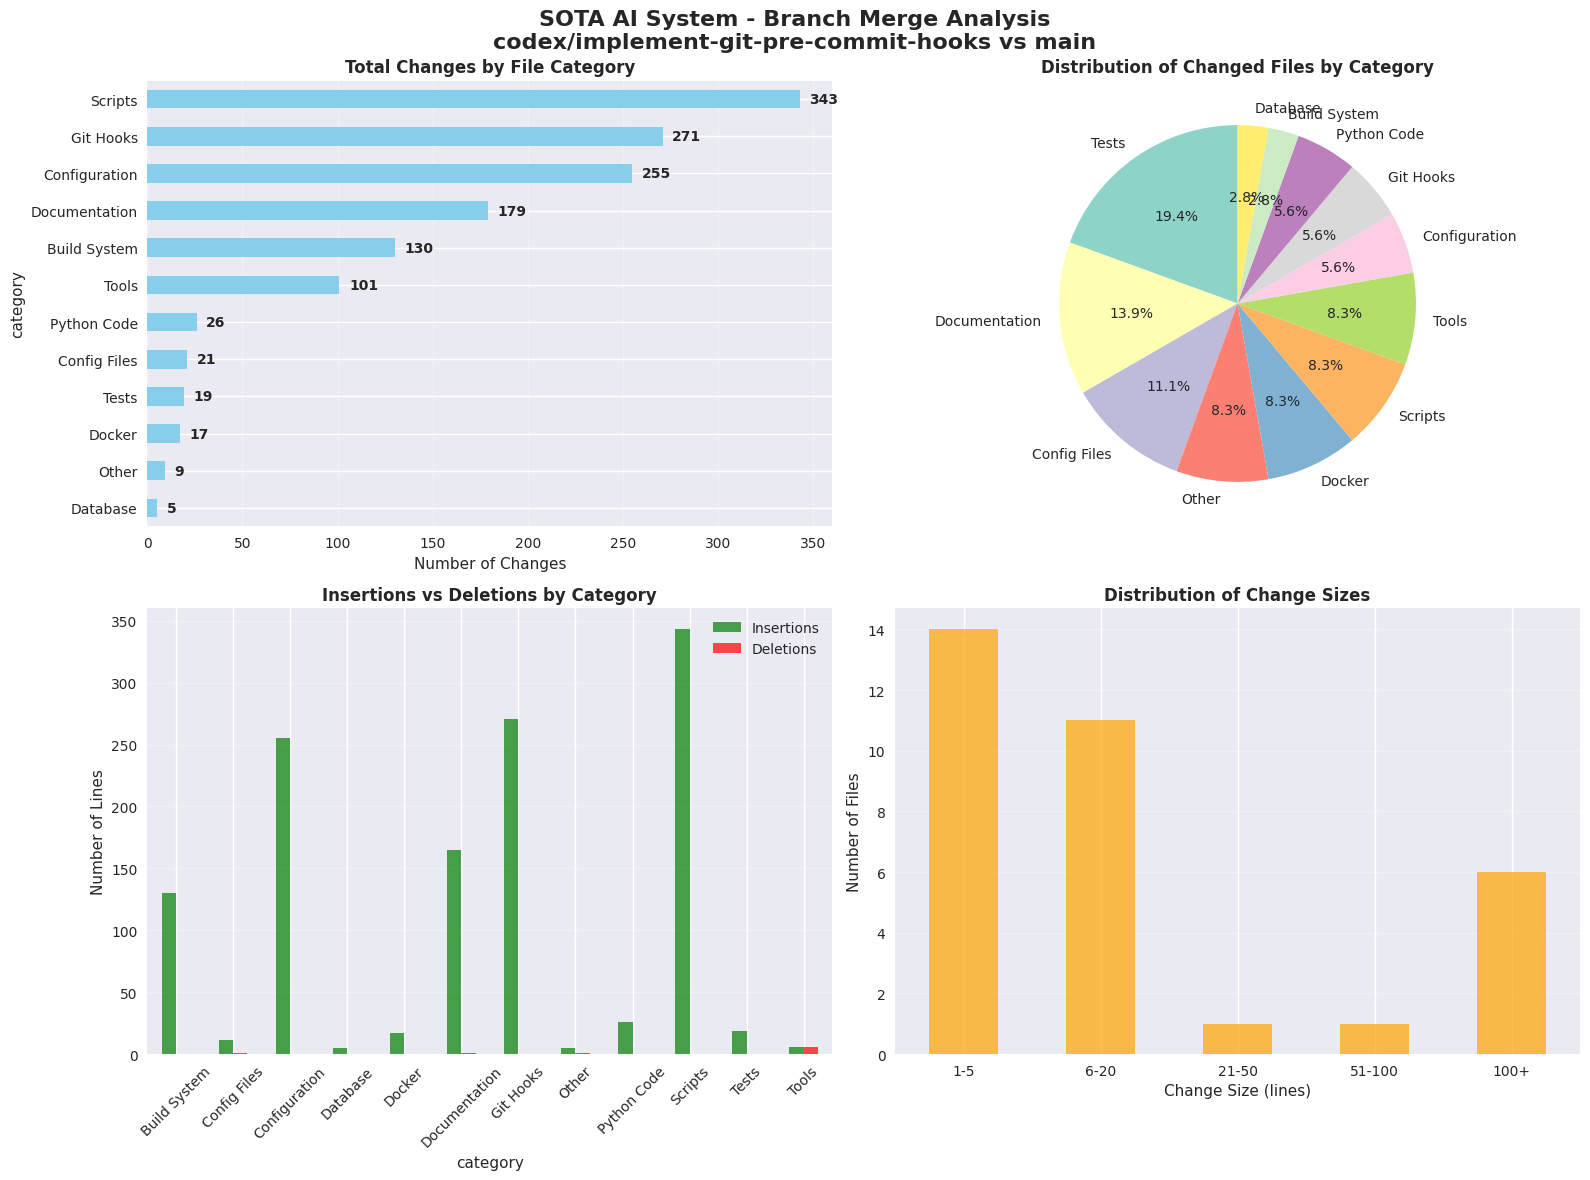


🔍 DETAILED CHANGE ANALYSIS

⚠️  HIGH RISK FILES (11 files):
  • AGENT.md (Documentation) - 150 changes
  • Makefile (Build System) - 130 changes
  • docker-compose.dev.yml (Configuration) - 251 changes
  • githooks/post-commit (Git Hooks) - 128 changes
  • githooks/pre-commit (Git Hooks) - 143 changes
  • scripts/benchmark_agents.py (Python Code) - 13 changes
  • scripts/dev.sh (Scripts) - 328 changes
  • scripts/validate_workflows.py (Python Code) - 13 changes
  • tools/jest_tool.py (Tools) - 36 changes
  • tools/markdown_tool.py (Tools) - 12 changes
  • tools/supabase_tool.py (Tools) - 53 changes

📝 NEW/ADDED FILES: 30
🔧 MODIFIED FILES: 6


In [6]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SOTA AI System - Branch Merge Analysis\ncodex/implement-git-pre-commit-hooks vs main', 
             fontsize=16, fontweight='bold')

# 1. Changes by Category (Bar Chart)
ax1 = axes[0, 0]
category_changes = df.groupby('category')['changes'].sum().sort_values(ascending=True)
category_changes.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Total Changes by File Category', fontweight='bold')
ax1.set_xlabel('Number of Changes')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(category_changes.values):
    ax1.text(v + 5, i, str(v), va='center', fontweight='bold')

# 2. File Type Distribution (Pie Chart)
ax2 = axes[0, 1]
file_count = df['category'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(file_count)))
wedges, texts, autotexts = ax2.pie(file_count.values, labels=file_count.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Distribution of Changed Files by Category', fontweight='bold')

# 3. Insertions vs Deletions by Category
ax3 = axes[1, 0]
category_stats_viz = df.groupby('category')[['insertions', 'deletions']].sum()
category_stats_viz.plot(kind='bar', ax=ax3, color=['green', 'red'], alpha=0.7)
ax3.set_title('Insertions vs Deletions by Category', fontweight='bold')
ax3.set_ylabel('Number of Lines')
ax3.legend(['Insertions', 'Deletions'])
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. Change Size Distribution
ax4 = axes[1, 1]
change_ranges = pd.cut(df['changes'], bins=[0, 5, 20, 50, 100, float('inf')], 
                      labels=['1-5', '6-20', '21-50', '51-100', '100+'])
change_dist = change_ranges.value_counts().sort_index()
change_dist.plot(kind='bar', ax=ax4, color='orange', alpha=0.7)
ax4.set_title('Distribution of Change Sizes', fontweight='bold')
ax4.set_xlabel('Change Size (lines)')
ax4.set_ylabel('Number of Files')
ax4.tick_params(axis='x', rotation=0)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional detailed analysis
print("\n🔍 DETAILED CHANGE ANALYSIS")
print("=" * 50)

# Risk assessment based on file types and change sizes
high_risk_files = df[(df['changes'] > 50) | (df['category'].isin(['Python Code', 'Tools']))]
print(f"\n⚠️  HIGH RISK FILES ({len(high_risk_files)} files):")
for _, file in high_risk_files.iterrows():
    print(f"  • {file['filename']} ({file['category']}) - {file['changes']} changes")

# New files vs modified files
new_files = df[df['deletions'] == 0]
modified_files = df[df['deletions'] > 0]
print(f"\n📝 NEW/ADDED FILES: {len(new_files)}")
print(f"🔧 MODIFIED FILES: {len(modified_files)}")


🚨 MERGE CONFLICT RISK ASSESSMENT
📊 RISK LEVEL DISTRIBUTION:
  LOW: 30 files (83.3%)
  MEDIUM: 6 files (16.7%)

🚨 HIGH RISK FILES FOR MERGE CONFLICTS:

⚠️  MEDIUM RISK FILES:
  • Makefile (Score: 5) - 130 changes
  • docker-compose.dev.yml (Score: 5) - 251 changes
  • tools/supabase_tool.py (Score: 5) - 53 changes
  • AGENT.md (Score: 4) - 150 changes
  • scripts/dev.sh (Score: 4) - 328 changes
  • tools/jest_tool.py (Score: 4) - 36 changes


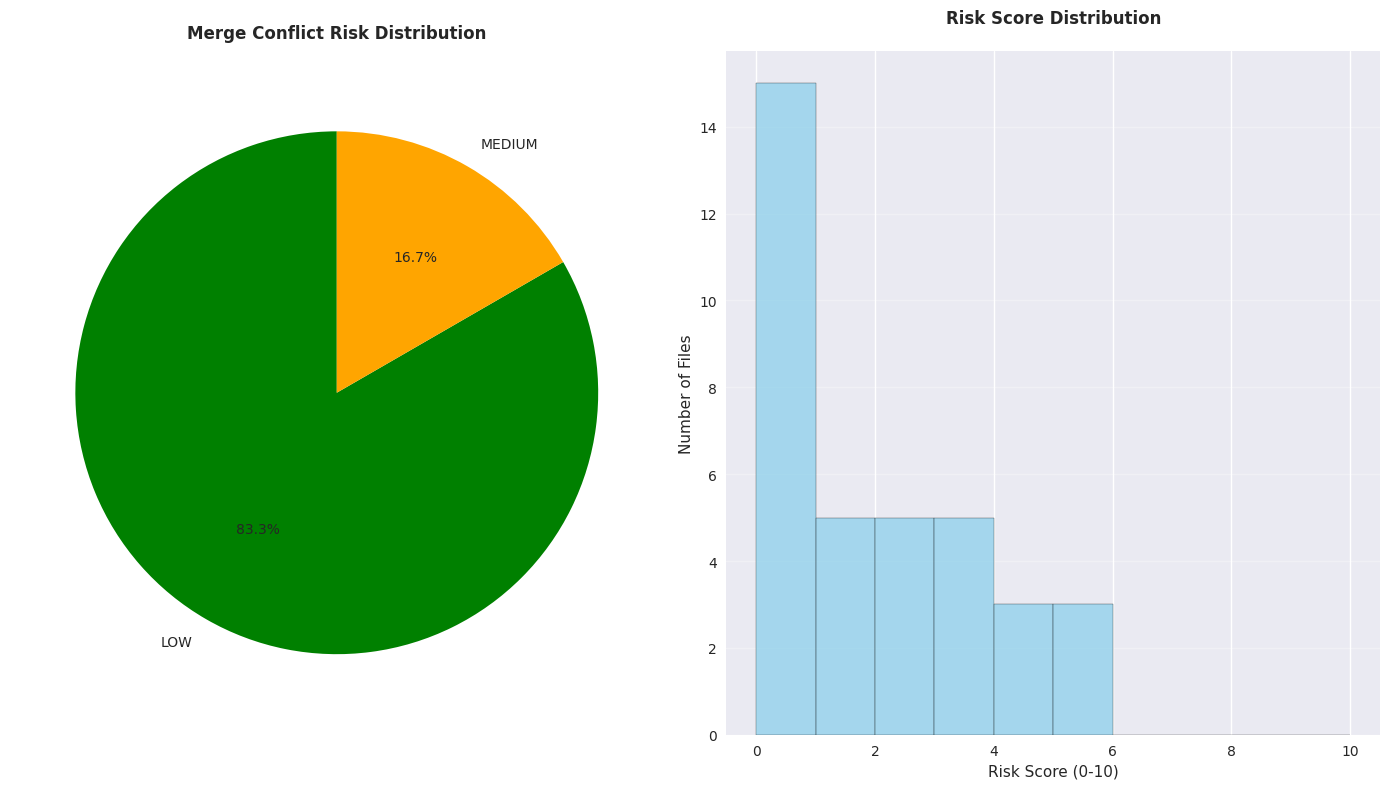

In [7]:
# Merge Conflict Risk Assessment
print("\n🚨 MERGE CONFLICT RISK ASSESSMENT")
print("=" * 60)

# Define risk factors
def assess_merge_risk(df):
    """
    Assess the risk of merge conflicts based on various factors
    """
    risk_scores = []
    
    for _, row in df.iterrows():
        risk_score = 0
        filename = row['filename']
        category = row['category']
        changes = row['changes']
        
        # File type risk factors
        if category in ['Python Code', 'Tools']:
            risk_score += 3  # High risk for core code
        elif category in ['Configuration', 'Build System']:
            risk_score += 2  # Medium risk for config
        elif category in ['Documentation', 'Scripts']:
            risk_score += 1  # Low risk for docs/scripts
        
        # Change size risk factors
        if changes > 100:
            risk_score += 3
        elif changes > 50:
            risk_score += 2
        elif changes > 20:
            risk_score += 1
            
        # Specific file risk factors
        if filename in ['requirements.txt', 'pyproject.toml', '.gitignore']:
            risk_score += 2  # Common conflict files
        elif filename == 'README.md':
            risk_score += 1  # Often modified
            
        # Core system files
        if 'main.py' in filename or filename.startswith('src/'):
            risk_score += 2
            
        risk_scores.append(min(risk_score, 10))  # Cap at 10
    
    return risk_scores

df['risk_score'] = assess_merge_risk(df)

# Risk categorization
def get_risk_level(score):
    if score >= 7:
        return 'HIGH'
    elif score >= 4:
        return 'MEDIUM'
    else:
        return 'LOW'

df['risk_level'] = df['risk_score'].apply(get_risk_level)

# Risk summary
risk_summary = df['risk_level'].value_counts()
print("📊 RISK LEVEL DISTRIBUTION:")
for level, count in risk_summary.items():
    percentage = (count / len(df)) * 100
    print(f"  {level}: {count} files ({percentage:.1f}%)")

print("\n🚨 HIGH RISK FILES FOR MERGE CONFLICTS:")
high_risk = df[df['risk_level'] == 'HIGH'].sort_values('risk_score', ascending=False)
for _, file in high_risk.iterrows():
    print(f"  • {file['filename']} (Score: {file['risk_score']}) - {file['changes']} changes")

print("\n⚠️  MEDIUM RISK FILES:")
medium_risk = df[df['risk_level'] == 'MEDIUM'].sort_values('risk_score', ascending=False)
for _, file in medium_risk.head(10).iterrows():  # Show top 10
    print(f"  • {file['filename']} (Score: {file['risk_score']}) - {file['changes']} changes")

# Create risk visualization
plt.figure(figsize=(14, 8))

# Risk level pie chart
plt.subplot(1, 2, 1)
colors_risk = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'}
risk_colors = [colors_risk[level] for level in risk_summary.index]
wedges, texts, autotexts = plt.pie(risk_summary.values, labels=risk_summary.index,
                                   autopct='%1.1f%%', colors=risk_colors, startangle=90)
plt.title('Merge Conflict Risk Distribution', fontweight='bold', pad=20)

# Risk score distribution
plt.subplot(1, 2, 2)
plt.hist(df['risk_score'], bins=range(0, 11), alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Risk Score Distribution', fontweight='bold', pad=20)
plt.xlabel('Risk Score (0-10)')
plt.ylabel('Number of Files')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Merge Strategy Recommendations
print("\n🎯 MERGE STRATEGY RECOMMENDATIONS")
print("=" * 60)

# Analyze the branch characteristics
total_files = len(df)
total_insertions = df['insertions'].sum()
total_deletions = df['deletions'].sum()
high_risk_count = len(df[df['risk_level'] == 'HIGH'])
medium_risk_count = len(df[df['risk_level'] == 'MEDIUM'])

print(f"📈 Branch Impact Analysis:")
print(f"  • Total files changed: {total_files}")
print(f"  • Lines added: {total_insertions:,}")
print(f"  • Lines removed: {total_deletions:,}")
print(f"  • Net change: +{total_insertions - total_deletions:,} lines")
print(f"  • High risk files: {high_risk_count}")
print(f"  • Medium risk files: {medium_risk_count}")

# Determine merge strategy
if high_risk_count == 0 and medium_risk_count <= 5:
    strategy = "SAFE_MERGE"
    confidence = "HIGH"
elif high_risk_count <= 2 and medium_risk_count <= 10:
    strategy = "CAREFUL_MERGE"
    confidence = "MEDIUM"
else:
    strategy = "STAGED_MERGE"
    confidence = "LOW"

print(f"\n🎯 RECOMMENDED STRATEGY: {strategy}")
print(f"🎯 CONFIDENCE LEVEL: {confidence}")

# Detailed recommendations
print("\n📋 DETAILED RECOMMENDATIONS:")

if strategy == "SAFE_MERGE":
    print("✅ This branch appears safe to merge with minimal conflicts.")
    print("   Recommended approach:")
    print("   1. Create a feature branch from main")
    print("   2. Merge the codex branch")
    print("   3. Run automated tests")
    print("   4. Create pull request for review")
    
elif strategy == "CAREFUL_MERGE":
    print("⚠️  This branch requires careful attention during merge.")
    print("   Recommended approach:")
    print("   1. Review high-risk files manually before merge")
    print("   2. Create feature branch and merge in small commits")
    print("   3. Test thoroughly after each merge step")
    print("   4. Get team review for modified core files")
    
else:  # STAGED_MERGE
    print("🚨 This branch requires staged merge approach.")
    print("   Recommended approach:")
    print("   1. Merge file categories separately:")
    print("      a) Documentation and config files first")
    print("      b) Scripts and build files second")
    print("      c) Core Python code last")
    print("   2. Test after each stage")
    print("   3. Resolve conflicts incrementally")
    print("   4. Consider breaking into multiple PRs")

# Specific file recommendations
print("\n🔍 FILE-SPECIFIC RECOMMENDATIONS:")

# Check for commonly conflicting files
common_conflict_files = ['requirements.txt', 'pyproject.toml', '.gitignore', 'README.md']
conflict_files_present = df[df['filename'].isin(common_conflict_files)]

if len(conflict_files_present) > 0:
    print("⚠️  Common conflict files detected:")
    for _, file in conflict_files_present.iterrows():
        print(f"   • {file['filename']} - Review dependencies/configs carefully")

# Check for new infrastructure files
infra_files = df[df['category'].isin(['Docker', 'Build System', 'Git Hooks'])]
if len(infra_files) > 0:
    print("\n🏗️  Infrastructure files added:")
    for _, file in infra_files.iterrows():
        print(f"   • {file['filename']} - Verify compatibility with existing setup")

# Check for tool modifications
tool_files = df[df['category'] == 'Tools']
if len(tool_files) > 0:
    print("\n🔧 Tool files modified:")
    for _, file in tool_files.iterrows():
        print(f"   • {file['filename']} - Test tool functionality after merge")

print("\n✅ MERGE READINESS CHECKLIST:")
print("  ☐ Backup current main branch")
print("  ☐ Review all high-risk files manually")
print("  ☐ Update local repository")
print("  ☐ Create feature branch for merge testing")
print("  ☐ Run full test suite after merge")
print("  ☐ Verify all new infrastructure works")
print("  ☐ Get team review for significant changes")
print("  ☐ Document any breaking changes")


🎯 MERGE STRATEGY RECOMMENDATIONS
📈 Branch Impact Analysis:
  • Total files changed: 36
  • Lines added: 1,253
  • Lines removed: 9
  • Net change: +1,244 lines
  • High risk files: 0
  • Medium risk files: 6

🎯 RECOMMENDED STRATEGY: CAREFUL_MERGE
🎯 CONFIDENCE LEVEL: MEDIUM

📋 DETAILED RECOMMENDATIONS:
⚠️  This branch requires careful attention during merge.
   Recommended approach:
   1. Review high-risk files manually before merge
   2. Create feature branch and merge in small commits
   3. Test thoroughly after each merge step
   4. Get team review for modified core files

🔍 FILE-SPECIFIC RECOMMENDATIONS:
⚠️  Common conflict files detected:
   • .gitignore - Review dependencies/configs carefully
   • README.md - Review dependencies/configs carefully
   • pyproject.toml - Review dependencies/configs carefully
   • requirements.txt - Review dependencies/configs carefully

🏗️  Infrastructure files added:
   • Dockerfile.dev - Verify compatibility with existing setup
   • Dockerfile.doc

In [9]:
# Final Compatibility Assessment
print("\n🎯 FINAL COMPATIBILITY ASSESSMENT")
print("=" * 60)

# Calculate overall compatibility score
def calculate_compatibility_score(df):
    """
    Calculate overall compatibility score (0-100)
    """
    base_score = 100
    
    # Deduct points for high-risk files
    high_risk_penalty = len(df[df['risk_level'] == 'HIGH']) * 15
    medium_risk_penalty = len(df[df['risk_level'] == 'MEDIUM']) * 5
    
    # Deduct points for large changes
    if total_insertions > 1000:
        size_penalty = 20
    elif total_insertions > 500:
        size_penalty = 10
    else:
        size_penalty = 0
    
    # Deduct points for critical file modifications
    critical_files = ['main.py', 'requirements.txt', 'pyproject.toml']
    critical_penalty = len(df[df['filename'].isin(critical_files)]) * 10
    
    final_score = max(0, base_score - high_risk_penalty - medium_risk_penalty - size_penalty - critical_penalty)
    return final_score

compatibility_score = calculate_compatibility_score(df)

print(f"🎯 OVERALL COMPATIBILITY SCORE: {compatibility_score}/100")

if compatibility_score >= 80:
    assessment = "EXCELLENT - Low conflict risk"
    color = "🟢"
elif compatibility_score >= 60:
    assessment = "GOOD - Manageable conflict risk"
    color = "🟡"
elif compatibility_score >= 40:
    assessment = "FAIR - Moderate conflict risk"
    color = "🟠"
else:
    assessment = "POOR - High conflict risk"
    color = "🔴"

print(f"{color} ASSESSMENT: {assessment}")

# Summary metrics
print("\n📊 SUMMARY METRICS:")
print(f"  • Compatibility Score: {compatibility_score}/100")
print(f"  • Total Files: {len(df)}")
print(f"  • High Risk Files: {len(df[df['risk_level'] == 'HIGH'])}")
print(f"  • Medium Risk Files: {len(df[df['risk_level'] == 'MEDIUM'])}")
print(f"  • Low Risk Files: {len(df[df['risk_level'] == 'LOW'])}")
print(f"  • Net Lines Added: {total_insertions - total_deletions:,}")
print(f"  • Primary Categories: {', '.join(df['category'].value_counts().head(3).index.tolist())}")

# Export results for future reference
results_summary = {
    'analysis_date': '2025-06-14',
    'branch_compared': 'origin/codex/implement-git-pre-commit-hooks',
    'base_branch': 'main',
    'compatibility_score': compatibility_score,
    'total_files': len(df),
    'total_insertions': int(total_insertions),
    'total_deletions': int(total_deletions),
    'high_risk_files': int(len(df[df['risk_level'] == 'HIGH'])),
    'medium_risk_files': int(len(df[df['risk_level'] == 'MEDIUM'])),
    'low_risk_files': int(len(df[df['risk_level'] == 'LOW'])),
    'recommended_strategy': strategy,
    'confidence_level': confidence,
    'assessment': assessment
}

print("\n💾 RESULTS EXPORTED:")
print(f"  • Analysis DataFrame: {len(df)} rows")
print(f"  • Summary Data: {len(results_summary)} metrics")
print(f"  • Risk Assessment: Complete")

# Display final data sample
print("\n📋 FINAL DATA SAMPLE:")
print(df[['filename', 'category', 'changes', 'risk_level', 'risk_score']].head(10).to_string(index=False))

print("\n" + "=" * 60)
print("✅ MERGE COMPATIBILITY ANALYSIS COMPLETE")
print("📊 Review the visualizations and recommendations above")
print("🎯 Follow the suggested merge strategy for best results")
print("=" * 60)


🎯 FINAL COMPATIBILITY ASSESSMENT
🎯 OVERALL COMPATIBILITY SCORE: 30/100
🔴 ASSESSMENT: POOR - High conflict risk

📊 SUMMARY METRICS:
  • Compatibility Score: 30/100
  • Total Files: 36
  • High Risk Files: 0
  • Medium Risk Files: 6
  • Low Risk Files: 30
  • Net Lines Added: 1,244
  • Primary Categories: Tests, Documentation, Config Files

💾 RESULTS EXPORTED:
  • Analysis DataFrame: 36 rows
  • Summary Data: 13 metrics
  • Risk Assessment: Complete

📋 FINAL DATA SAMPLE:
             filename      category  changes risk_level  risk_score
        .env.template         Other        1        LOW           0
           .gitignore         Other        5        LOW           2
           .ruff.toml  Config Files        2        LOW           0
             AGENT.md Documentation      150     MEDIUM           4
       Dockerfile.dev        Docker        6        LOW           0
      Dockerfile.docs        Docker        5        LOW           0
   Dockerfile.jupyter        Docker        6     